<a href="https://colab.research.google.com/github/matheusmello-o/turnover-optmization/blob/main/turnover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://github.com/matheusmello-o/turnover-optmization/raw/main/files/Base_dados%20-%20Rotatividade%20RH.xlsx'


df = pd.read_excel(url, engine='openpyxl')
df.columns = df.columns.str.lower()
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_contratacao      650 non-null    datetime64[ns]
 1   data_desligamento     144 non-null    datetime64[ns]
 2   meses_de_servico      650 non-null    int64         
 3   idade                 650 non-null    int64         
 4   pontuacao_desempenho  650 non-null    float64       
 5   satisfacao_trabalho   650 non-null    float64       
 6   nivel_cargo           650 non-null    object        
 7   salario               650 non-null    float64       
 8   horas_extras          650 non-null    float64       
 9   desligamento          650 non-null    int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(1)
memory usage: 50.9+ KB


In [ ]:
df.describe()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,salario,horas_extras,desligamento
count,650,144,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000
mean,2022-10-31 06:38:46.153846272,2024-05-14 00:00:00,18.690769,28.349231,3.027463,2.940577,6131.587062,10.098864,0.221538
min,2021-06-29 00:00:00,2024-05-14 00:00:00,3.000000,18.000000,1.000242,1.002868,2004.500000,0.003734,0.000000
25%,2022-02-24 00:00:00,2024-05-14 00:00:00,10.000000,22.000000,1.988753,1.968571,4023.752500,4.978000,0.000000
50%,2022-10-22 00:00:00,2024-05-14 00:00:00,19.000000,27.000000,3.058911,2.923458,5562.950000,9.413546,0.000000
75%,2023-07-19 00:00:00,2024-05-14 00:00:00,27.000000,33.000000,4.022709,3.964356,7814.480000,14.749310,0.000000
max,2024-02-14 00:00:00,2024-05-14 00:00:00,35.000000,49.000000,4.992102,4.999415,11957.290000,41.638350,1.000000
std,NaN,NaN,9.652262,8.014983,1.174226,1.148514,2689.075566,6.242406,0.415602


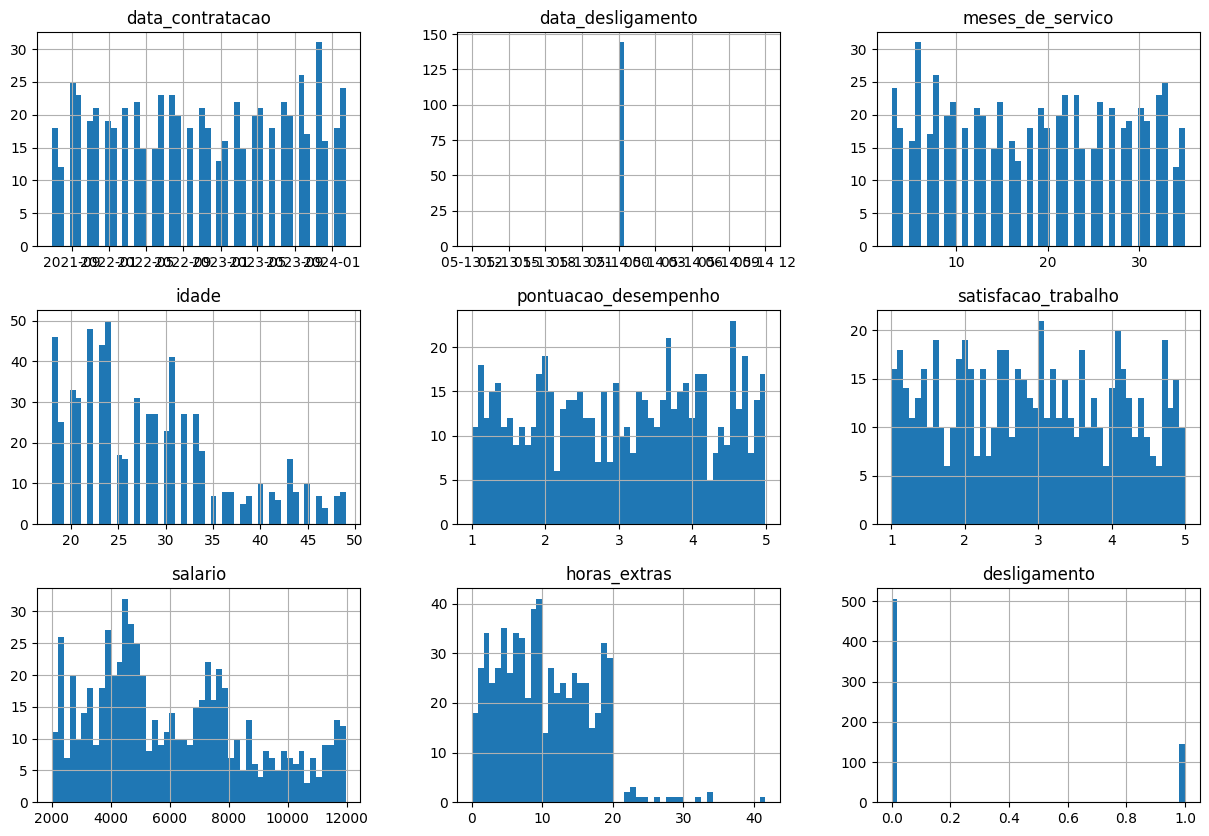

In [ ]:
df.hist(bins = 50, figsize=(15, 10))
plt.show()

In [ ]:
df.isnull().sum()

data_contratacao          0
data_desligamento       506
meses_de_servico          0
idade                     0
pontuacao_desempenho      0
satisfacao_trabalho       0
nivel_cargo               0
salario                   0
horas_extras              0
desligamento              0
dtype: int64

In [ ]:
df.nivel_cargo.value_counts()

nivel_cargo
Junior    233
Pleno     225
Sênior    192
Name: count, dtype: int64

In [ ]:
print('Data min de desligamento: ', df.data_desligamento.min())
print('Data max de desligamento: ', df.data_desligamento.max())

print('Data min de contratacao: ', df.data_contratacao.min())
print('Data max de contratacao: ', df.data_contratacao.max())

Data min de desligamento:  2024-05-14 00:00:00
Data max de desligamento:  2024-05-14 00:00:00
Data min de contratacao:  2021-06-29 00:00:00
Data max de contratacao:  2024-02-14 00:00:00


<Axes: xlabel='meses_de_servico', ylabel='data_contratacao'>

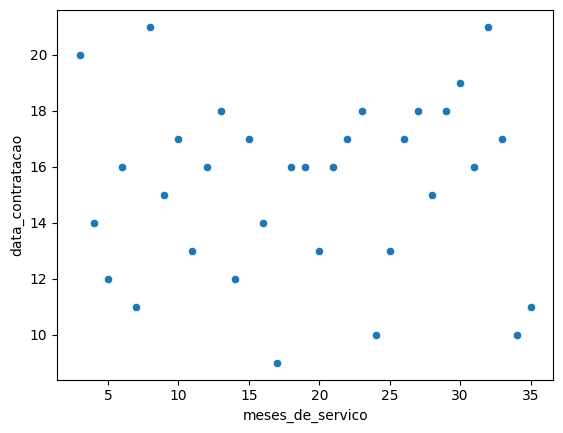

In [ ]:
service_fired = df.loc[df.desligamento == 0].groupby(['meses_de_servico']).data_contratacao.count().reset_index()

sns.scatterplot(data=service_fired,
                x = 'meses_de_servico',
                y = 'data_contratacao')

# <font color = 'gold'> Data Exploration </font>

In [ ]:
# quantidade de pessoas desligadas
# quantidade de pessoas contratadas

total_colaboradores = df.shape[0]
desligamentos = df.desligamento.sum()
colaboradores_ativos = total_colaboradores - desligamentos
turnover = ((total_colaboradores + desligamentos) / 2) / colaboradores_ativos

print('Taxa de turnover:', turnover)
print('Pessoas ativas: ', colaboradores_ativos)
print('Pessoas desligadas: ', desligamentos)

Taxa de turnover: 0.7845849802371542
Pessoas ativas:  506
Pessoas desligadas:  144


In [ ]:
#retenção dos funcionarios

def taxa_retencao(df, cargo = ''):
    if cargo == '':
        total_colaboradores = df.shape[0]
        desligamentos = df.desligamento.sum()
        colaboradores_ativos = total_colaboradores - desligamentos
        return colaboradores_ativos / total_colaboradores
    else:
        filtro_cargo = df.nivel_cargo == cargo
        df_filter = df.loc[filtro_cargo]
        total_colaboradores = df_filter.shape[0]
        desligamentos = df_filter.desligamento.sum()
        colaboradores_ativos = total_colaboradores - desligamentos
        return colaboradores_ativos / total_colaboradores

taxa_retencao_geral = taxa_retencao(df)
taxa_retencao_junior = taxa_retencao(df, cargo = 'Junior')
taxa_retencao_pleno = taxa_retencao(df, cargo = 'Pleno')
taxa_retencao_senior = taxa_retencao(df, cargo = 'Sênior')


print('Taxa de retencao: ', taxa_retencao_geral)
print('Taxa de retencao Junior: ', taxa_retencao_junior)
print('Taxa de retencao Pleno: ', taxa_retencao_pleno)
print('Taxa de retencao Senior: ', taxa_retencao_senior)


Taxa de retencao:  0.7784615384615384
Taxa de retencao Junior:  0.759656652360515
Taxa de retencao Pleno:  0.8
Taxa de retencao Senior:  0.7760416666666666


<Axes: >

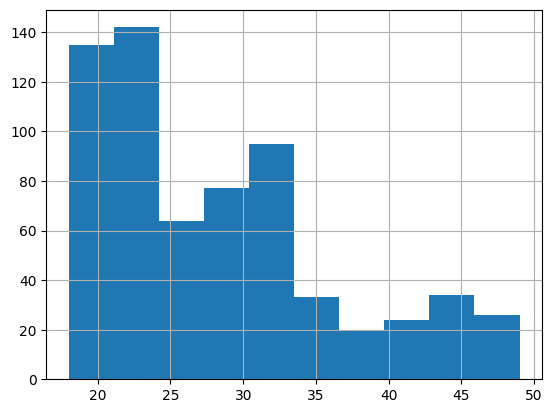

In [ ]:
# taxa de rentecao por idade



In [ ]:
labels = [1, 2, 3, 4]
bins = [18, 25, 30, 35, 40, np.inf]

df['idade_group'] = pd.cut(df.idade, bins=bins, labels=labels)
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento,idade_group
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0,1
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1,3
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0,3
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0,2
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0,2


<Axes: >

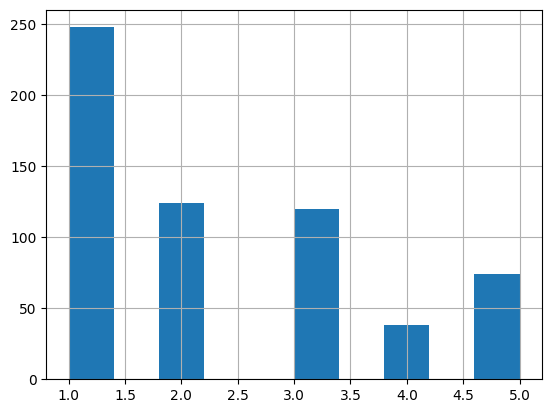

In [ ]:
df.idade_group.hist()

In [ ]:
df.groupby('idade_group').idade.count()

idade_group
1    248
2    124
3    120
4     38
5     74
Name: idade, dtype: int64

In [ ]:
def taxa_retencao_idade(df, idade):
    filtro_cargo = df.idade_group == idade
    df_filter = df.loc[filtro_cargo]
    total_colaboradores = df_filter.shape[0]
    desligamentos = df_filter.desligamento.sum()
    colaboradores_ativos = total_colaboradores - desligamentos
    return colaboradores_ativos / total_colaboradores

for ig in df.idade_group.unique():
    print(f'Taxa de retencao grupo {ig}: {taxa_retencao_idade(df, idade = ig)}')

Taxa de retencao grupo 1: 0.782258064516129
Taxa de retencao grupo 5: 0.7702702702702703
Taxa de retencao grupo 3: 0.775
Taxa de retencao grupo 4: 0.7105263157894737
Taxa de retencao grupo 2: 0.7983870967741935
Taxa de retencao grupo nan: nan


<ipython-input-42-4bfc827a0dd2>:7: RuntimeWarning: invalid value encountered in scalar divide
  return colaboradores_ativos / total_colaboradores


<Axes: ylabel='salario'>

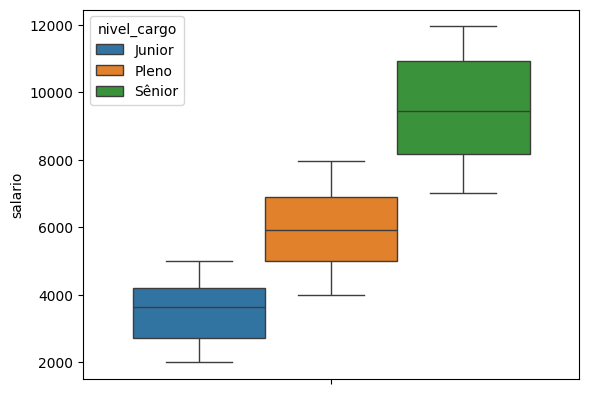

In [ ]:
sns.boxplot(data = df,
            y = 'salario',
            hue = 'nivel_cargo',
            hue_order = ['Junior', 'Pleno', 'Sênior'])